In [ ]:
# Install once in terminal:
# pip install yfinance pandas numpy scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import math
import numpy as np
import pandas as pd
import yfinance as yf

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [4]:
DEFAULT_CONFIG = {
    "start_date": "2000-01-01",
    "end_date": None,
    "random_state": 42,
    "n_estimators": 500,
    "max_depth": 8,
    "min_samples_leaf": 2,
    "use_manual_event_flags": True
}

In [5]:
def download_market_data(start_date: str, end_date=None) -> pd.DataFrame:
    ticker_candidates = {
        "gold": ["GC=F", "GLD"],
        "sp500": ["^GSPC", "SPY"],
        "vix": ["^VIX"],
        "usd_proxy": ["UUP", "DX-Y.NYB"],
        "oil": ["CL=F", "BZ=F"],
        "tnx": ["^TNX"],
        "btc": ["BTC-USD"]
    }

    def fetch_close_series(symbol: str):
        data = yf.download(symbol, start=start_date, end=end_date, auto_adjust=True, progress=False)
        if data is None or data.empty or "Close" not in data.columns:
            return None

        close_data = data["Close"]

        if isinstance(close_data, pd.DataFrame):
            if close_data.shape[1] == 0:
                return None
            s = close_data.iloc[:, 0]
        else:
            s = close_data

        s = pd.to_numeric(s, errors="coerce").dropna()
        return s if not s.empty else None

    frames = []

    for col_name, candidates in ticker_candidates.items():
        for sym in candidates:
            s = fetch_close_series(sym)
            if s is not None:
                frames.append(s.rename(col_name))
                break

    df = pd.concat(frames, axis=1).sort_index()
    df = df.ffill().dropna()

    return df

In [6]:
def apply_manual_event_flags(monthly_df: pd.DataFrame) -> pd.DataFrame:
    m = monthly_df.copy()

    m.loc[(m.index >= "2020-03-01") & (m.index <= "2020-06-01"), "global_crisis_flag"] = 1
    m.loc[(m.index >= "2022-02-01") & (m.index <= "2023-12-01"), "war_shock_flag"] = 1
    m.loc[(m.index >= "2021-06-01") & (m.index <= "2023-06-01"), "inflation_shock_flag"] = 1

    return m

In [ ]:
def make_monthly_features(daily_df: pd.DataFrame, use_manual_event_flags=True):
    df = daily_df.copy()

    for c in ["gold", "sp500", "usd_proxy", "oil", "btc"]:
        df[f"{c}_ret_1d"] = df[c].pct_change()

    monthly = pd.DataFrame(index=df.resample("MS").mean().index)

    for c in ["gold", "sp500", "vix", "usd_proxy", "oil", "tnx", "btc"]:
        monthly[f"{c}_avg"] = df[c].resample("MS").mean()

    for c in ["gold", "sp500", "usd_proxy", "oil", "btc"]:
        monthly[f"{c}_mom"] = monthly[f"{c}_avg"].pct_change()

    for c in ["gold", "sp500", "usd_proxy", "oil", "btc"]:
        monthly[f"{c}_rv"] = df[f"{c}_ret_1d"].resample("MS").std()

    monthly["fear_flag"] = (monthly["vix_avg"] >= monthly["vix_avg"].rolling(24).median() * 1.2).astype(int)

    if use_manual_event_flags:
        monthly = apply_manual_event_flags(monthly)
    else:
        monthly["global_crisis_flag"] = 0
        monthly["war_shock_flag"] = 0
        monthly["inflation_shock_flag"] = 0

    monthly[["global_crisis_flag", "war_shock_flag", "inflation_shock_flag"]] = (
        monthly[["global_crisis_flag", "war_shock_flag", "inflation_shock_flag"]]
        .fillna(0)
        .astype(int)
    )

    for lag in [1, 2, 3, 6, 12]:
        monthly[f"gold_lag_{lag}"] = monthly["gold_avg"].shift(lag)

    monthly["target_next_gold"] = monthly["gold_avg"].shift(-1)

    monthly = monthly.dropna()

    return monthly

In [8]:
def train_model(monthly_df, config):
    features = [col for col in monthly_df.columns if col != "target_next_gold"]

    X = monthly_df[features]
    y = monthly_df["target_next_gold"]

    split_idx = int(len(monthly_df) * 0.85)

    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    model = RandomForestRegressor(
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        min_samples_leaf=config["min_samples_leaf"],
        random_state=config["random_state"]
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    print("MAE:", mean_absolute_error(y_test, preds))
    print("RMSE:", math.sqrt(mean_squared_error(y_test, preds)))

    return model

In [9]:
daily = download_market_data("2000-01-01")
monthly = make_monthly_features(daily)

model = train_model(monthly, DEFAULT_CONFIG)

MAE: 1219.066760413963
RMSE: 1452.9969766743366


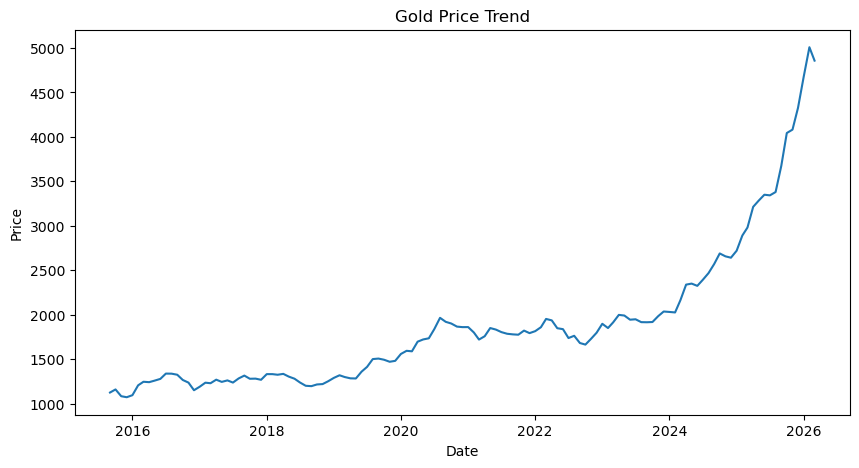

In [10]:
plt.figure(figsize=(10,5))
plt.plot(monthly.index, monthly["gold_avg"])
plt.title("Gold Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [11]:
importances = model.feature_importances_
features = [col for col in monthly.columns if col != "target_next_gold"]

fi = pd.DataFrame({"Feature": features, "Importance": importances})
fi = fi.sort_values("Importance", ascending=False)

fi.head(10)

,Feature,Importance
0,gold_avg,0.262816
19,gold_lag_2,0.208494
18,gold_lag_1,0.203154
21,gold_lag_6,0.165288
20,gold_lag_3,0.086490
1,sp500_avg,0.035532
3,usd_proxy_avg,0.015328
6,btc_avg,0.006094
5,tnx_avg,0.003168
22,gold_lag_12,0.003102


In [ ]:
def run_end_to_end(
    forecast_start="2026-05-01",
    forecast_months=20,
    scenario="baseline",
    vix_bump_pct=0.0,
    oil_bump_pct=0.0,
    tnx_bump_pct=0.0,
    usd_bump_pct=0.0
):
    """
    End-to-end forecast pipeline: download data, train model, generate forecast.
    
    Returns:
        dict with keys: forecast, monthly, metrics, feature_importance
    """
    # 1) Download and prepare data
    daily = download_market_data(DEFAULT_CONFIG["start_date"], DEFAULT_CONFIG["end_date"])
    monthly = make_monthly_features(
        daily,
        use_manual_event_flags=DEFAULT_CONFIG.get("use_manual_event_flags", True)
    )

    # 2) Train model
    features = [c for c in monthly.columns if c != "target_next_gold"]
    X = monthly[features]
    y = monthly["target_next_gold"]

    split_idx = int(len(monthly) * 0.85)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    model = RandomForestRegressor(
        n_estimators=DEFAULT_CONFIG["n_estimators"],
        max_depth=DEFAULT_CONFIG["max_depth"],
        min_samples_leaf=DEFAULT_CONFIG["min_samples_leaf"],
        random_state=DEFAULT_CONFIG["random_state"]
    )
    model.fit(X_train, y_train)

    # 3) Compute metrics
    preds_test = model.predict(X_test)
    mae = float(mean_absolute_error(y_test, preds_test))
    rmse = float(math.sqrt(mean_squared_error(y_test, preds_test)))
    
    denom = np.clip(np.abs(y_test.values), 1e-9, None)
    mape = float(np.mean(np.abs((y_test.values - preds_test) / denom)) * 100.0)

    metrics = {"MAE": mae, "RMSE": rmse, "MAPE_%": mape}

    # 4) Feature importance
    fi = pd.DataFrame({
        "feature": features,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False).reset_index(drop=True)

    # 5) Generate forecast
    start = pd.to_datetime(forecast_start)
    idx = pd.date_range(start=start, periods=int(forecast_months), freq="MS")

    scenario_mult = {"baseline": 1.00, "crisis": 1.04, "risk_on": 0.98}.get(scenario, 1.00)
    
    shock = (
        0.0008 * float(vix_bump_pct)
        + 0.0005 * float(oil_bump_pct)
        - 0.0007 * float(tnx_bump_pct)
        - 0.0006 * float(usd_bump_pct)
    )

    last_row = X.iloc[-1].copy()
    preds = []
    
    residual = y_test.values - preds_test if len(y_test) > 0 else np.array([rmse])
    sigma = float(np.std(residual)) if len(residual) > 1 else max(1.0, rmse)

    for _ in idx:
        base = float(model.predict(last_row.values.reshape(1, -1))[0])
        pred = base * scenario_mult * (1.0 + shock)
        preds.append(pred)

        # Update lag features for next iteration
        for lag in [12, 6, 3, 2, 1]:
            dst = f"gold_lag_{lag}"
            if dst in last_row.index:
                if lag == 1:
                    last_row[dst] = pred
                else:
                    src = f"gold_lag_{lag - 1}"
                    if src in last_row.index:
                        last_row[dst] = last_row[src]

        if "gold_avg" in last_row.index:
            last_row["gold_avg"] = pred

    forecast = pd.DataFrame({
        "predicted_gold_avg": preds,
        "predicted_lower_95": np.array(preds) - 1.96 * sigma,
        "predicted_upper_95": np.array(preds) + 1.96 * sigma
    }, index=idx)

    return {
        "forecast": forecast,
        "monthly": monthly,
        "metrics": metrics,
        "feature_importance": fi
    }